In [1]:
# Environment setup: installs, imports, Drive mount, device check, seeds

!pip install -q lightly albumentations torchmetrics kagglehub gdown

import os
import random
import json
import numpy as np
import torch
import torchvision
from google.colab import drive

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Device check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type != "cuda":
    print("WARNING: GPU not detected. Go to Runtime > Change runtime type > T4 GPU before continuing.")

# Mount Drive for persistent storage of checkpoints, metrics, and figures
drive.mount('/content/drive')

# Project directory structure
PROJECT_ROOT = "/content/drive/MyDrive/ag_cv_project"
DATA_DIR = "/content/data"  # local fast disk, not persisted

for d in [
    PROJECT_ROOT,
    f"{PROJECT_ROOT}/checkpoints",
    f"{PROJECT_ROOT}/metrics",
    f"{PROJECT_ROOT}/figures",
    DATA_DIR,
]:
    os.makedirs(d, exist_ok=True)

print(f"Torch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

print("Setup complete. Project root:", PROJECT_ROOT)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 891.2/891.2 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.6/165.6 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.1/163.1 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 17.1 MB/s eta 0:00:00
Mounted at /content/drive
Torch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128
Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB
Setup complete. Project root: /content/drive/MyDrive/ag_cv_project


In [2]:
# Download PlantVillage (lab/source) and PlantDoc (field/target) via GitHub mirrors.
# Using GitHub instead of Kaggle avoids needing API credentials in Colab.

import subprocess
import time
from pathlib import Path

def run(cmd):
    # Run a shell command, stream output, raise on failure
    print(f"$ {cmd}")
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if result.stdout:
        print(result.stdout[-2000:])
    if result.returncode != 0:
        print(result.stderr[-3000:])
        raise RuntimeError(f"Command failed: {cmd}")

PV_DIR = f"{DATA_DIR}/plantvillage"
PD_DIR = f"{DATA_DIR}/plantdoc"

# PlantVillage: official mirror with raw/color, raw/grayscale, raw/segmented subsets
if not os.path.exists(PV_DIR):
    t0 = time.time()
    run(f"git clone --depth 1 https://github.com/spMohanty/PlantVillage-Dataset.git {PV_DIR}")
    print(f"PlantVillage cloned in {time.time()-t0:.1f}s")
else:
    print("PlantVillage already present, skipping clone.")

# PlantDoc: field images, train/test split with class subfolders
if not os.path.exists(PD_DIR):
    t0 = time.time()
    run(f"git clone --depth 1 https://github.com/pratikkayal/PlantDoc-Dataset.git {PD_DIR}")
    print(f"PlantDoc cloned in {time.time()-t0:.1f}s")
else:
    print("PlantDoc already present, skipping clone.")

# Verify PlantVillage structure (use the 'color' subset as our source domain)
pv_color_dir = Path(PV_DIR) / "raw" / "color"
assert pv_color_dir.exists(), f"Expected PlantVillage color dir not found: {pv_color_dir}"
pv_classes = sorted([d.name for d in pv_color_dir.iterdir() if d.is_dir()])
pv_counts = {c: len(list((pv_color_dir / c).glob("*"))) for c in pv_classes}
print(f"\nPlantVillage: {len(pv_classes)} classes, {sum(pv_counts.values())} total images")

# Verify PlantDoc structure (combine train + test folders for full class list)
pd_train_dir = Path(PD_DIR) / "train"
pd_test_dir = Path(PD_DIR) / "test"
assert pd_train_dir.exists() and pd_test_dir.exists(), "PlantDoc train/test dirs not found"
pd_classes = sorted(set(
    [d.name for d in pd_train_dir.iterdir() if d.is_dir()] +
    [d.name for d in pd_test_dir.iterdir() if d.is_dir()]
))
pd_counts = {}
for c in pd_classes:
    n_train = len(list((pd_train_dir / c).glob("*"))) if (pd_train_dir / c).exists() else 0
    n_test = len(list((pd_test_dir / c).glob("*"))) if (pd_test_dir / c).exists() else 0
    pd_counts[c] = n_train + n_test
print(f"PlantDoc: {len(pd_classes)} classes, {sum(pd_counts.values())} total images")

# Flag any classes with very low counts now, since this affects Cell 11's N=500 tier later
low_count_pd = {c: n for c, n in pd_counts.items() if n < 50}
if low_count_pd:
    print(f"\nWARNING: {len(low_count_pd)} PlantDoc classes have fewer than 50 images:")
    for c, n in sorted(low_count_pd.items(), key=lambda x: x[1]):
        print(f"  {c}: {n}")

# Save raw class lists and counts to Drive for use in Cell 3 (manual class alignment)
with open(f"{PROJECT_ROOT}/metrics/raw_class_inventory.json", "w") as f:
    json.dump({
        "plantvillage_classes": pv_counts,
        "plantdoc_classes": pd_counts,
    }, f, indent=2)

print("\nRaw class inventory saved to Drive.")
print("Data download complete.")

$ git clone --depth 1 https://github.com/spMohanty/PlantVillage-Dataset.git /content/data/plantvillage
PlantVillage cloned in 92.9s
$ git clone --depth 1 https://github.com/pratikkayal/PlantDoc-Dataset.git /content/data/plantdoc
PlantDoc cloned in 28.6s

PlantVillage: 38 classes, 54305 total images
PlantDoc: 28 classes, 2578 total images

  Tomato two spotted spider mites leaf: 2

Raw class inventory saved to Drive.
Data download complete.


Aligned classes (PD count >= 10): 27
Dropped classes (too few PD samples): {'Tomato two spotted spider mites leaf': 2}

PlantDoc class                           PV class                                        PD n   PV n
Apple Scab Leaf                          Apple___Apple_scab                                93    630
Apple leaf                               Apple___healthy                                   91   1645
Apple rust leaf                          Apple___Cedar_apple_rust                          89    275
Bell_pepper leaf                         Pepper,_bell___healthy                            61   1478
Bell_pepper leaf spot                    Pepper,_bell___Bacterial_spot                     71    997
Blueberry leaf                           Blueberry___healthy                              117   1502
Cherry leaf                              Cherry_(including_sour)___healthy                 57    854
Corn Gray leaf spot                      Corn_(maize)___Cercospora_leaf_

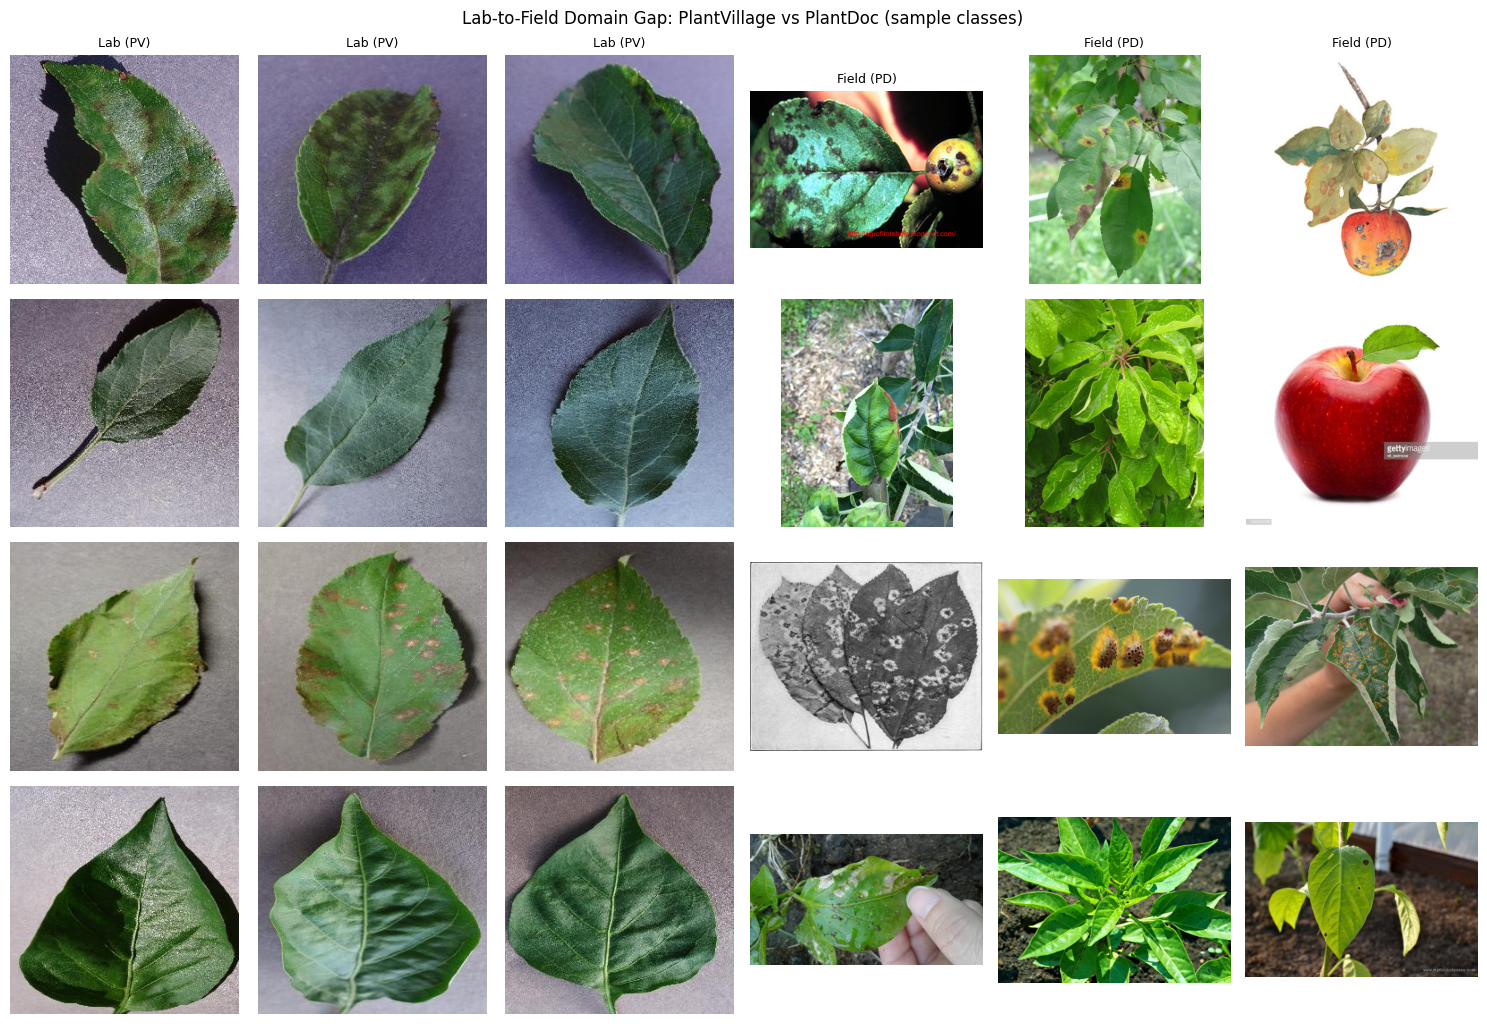


Final class count for experiments: 27
Aligned class mapping saved to Drive.
Preprocessing and EDA complete.


In [3]:
# Align PlantVillage (source) and PlantDoc (target) class taxonomies, run basic
# integrity checks, and visualize the domain gap for a few matched classes.

import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError

pv_color_dir = Path(PV_DIR) / "raw" / "color"
pd_train_dir = Path(PD_DIR) / "train"
pd_test_dir = Path(PD_DIR) / "test"

# Manual mapping: PlantDoc class name -> PlantVillage class name.
# Built from known folder-name correspondences between the two datasets.
# "healthy"-style PlantDoc classes (bare "X leaf") are mapped to PV's healthy class.
PD_TO_PV = {
    "Apple Scab Leaf": "Apple___Apple_scab",
    "Apple leaf": "Apple___healthy",
    "Apple rust leaf": "Apple___Cedar_apple_rust",
    "Bell_pepper leaf": "Pepper,_bell___healthy",
    "Bell_pepper leaf spot": "Pepper,_bell___Bacterial_spot",
    "Blueberry leaf": "Blueberry___healthy",
    "Cherry leaf": "Cherry_(including_sour)___healthy",
    "Corn Gray leaf spot": "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot",
    "Corn leaf blight": "Corn_(maize)___Northern_Leaf_Blight",
    "Corn rust leaf": "Corn_(maize)___Common_rust_",
    "grape leaf": "Grape___healthy",
    "grape leaf black rot": "Grape___Black_rot",
    "Peach leaf": "Peach___healthy",
    "Potato leaf early blight": "Potato___Early_blight",
    "Potato leaf late blight": "Potato___Late_blight",
    "Raspberry leaf": "Raspberry___healthy",
    "Soyabean leaf": "Soybean___healthy",
    "Squash Powdery mildew leaf": "Squash___Powdery_mildew",
    "Strawberry leaf": "Strawberry___healthy",
    "Tomato Early blight leaf": "Tomato___Early_blight",
    "Tomato Septoria leaf spot": "Tomato___Septoria_leaf_spot",
    "Tomato leaf": "Tomato___healthy",
    "Tomato leaf bacterial spot": "Tomato___Bacterial_spot",
    "Tomato leaf late blight": "Tomato___Late_blight",
    "Tomato leaf mosaic virus": "Tomato___Tomato_mosaic_virus",
    "Tomato leaf yellow virus": "Tomato___Tomato_Yellow_Leaf_Curl_Virus",
    "Tomato mold leaf": "Tomato___Leaf_Mold",
    "Tomato two spotted spider mites leaf": "Tomato___Spider_mites Two-spotted_spider_mite",
}

def pd_class_count(cls_name):
    n_train = len(list((pd_train_dir / cls_name).glob("*"))) if (pd_train_dir / cls_name).exists() else 0
    n_test = len(list((pd_test_dir / cls_name).glob("*"))) if (pd_test_dir / cls_name).exists() else 0
    return n_train + n_test

# Drop mapped classes with too few PlantDoc images to support even a small test split.
# Threshold of 10 keeps classes usable for the N={10,50,100,500} experiment while
# excluding degenerate cases like the 2-image spider-mite class.
MIN_PD_COUNT = 10
aligned = {}
dropped = {}
for pd_cls, pv_cls in PD_TO_PV.items():
    assert (pv_color_dir / pv_cls).exists(), f"PV class missing on disk: {pv_cls}"
    n_pd = pd_class_count(pd_cls)
    n_pv = len(list((pv_color_dir / pv_cls).glob("*")))
    if n_pd < MIN_PD_COUNT:
        dropped[pd_cls] = n_pd
        continue
    aligned[pd_cls] = {"pv_class": pv_cls, "pd_count": n_pd, "pv_count": n_pv}

print(f"Aligned classes (PD count >= {MIN_PD_COUNT}): {len(aligned)}")
print(f"Dropped classes (too few PD samples): {dropped}\n")

print(f"{'PlantDoc class':40s} {'PV class':45s} {'PD n':>6s} {'PV n':>6s}")
for pd_cls, info in sorted(aligned.items()):
    print(f"{pd_cls:40s} {info['pv_class']:45s} {info['pd_count']:6d} {info['pv_count']:6d}")

# Basic image integrity check: sample a handful of files per domain and confirm they open
def check_integrity(root_dir, class_names, n_per_class=5):
    bad_files = []
    for cls in class_names:
        files = list((root_dir / cls).glob("*"))[:n_per_class] if (root_dir / cls).exists() else []
        for f in files:
            try:
                with Image.open(f) as im:
                    im.verify()
            except (UnidentifiedImageError, OSError):
                bad_files.append(str(f))
    return bad_files

pv_bad = check_integrity(pv_color_dir, [v["pv_class"] for v in aligned.values()])
pd_bad_train = check_integrity(pd_train_dir, list(aligned.keys()))
pd_bad_test = check_integrity(pd_test_dir, list(aligned.keys()))
print(f"\nCorrupt files found - PlantVillage: {len(pv_bad)}, PlantDoc train: {len(pd_bad_train)}, PlantDoc test: {len(pd_bad_test)}")

# Visualize domain gap: pick 4 aligned classes, show 3 PV vs 3 PD samples each
sample_classes = list(aligned.keys())[:4]
fig, axes = plt.subplots(len(sample_classes), 6, figsize=(15, 2.6 * len(sample_classes)))
for row, pd_cls in enumerate(sample_classes):
    pv_cls = aligned[pd_cls]["pv_class"]
    pv_files = list((pv_color_dir / pv_cls).glob("*"))[:3]
    pd_files = (list((pd_train_dir / pd_cls).glob("*")) + list((pd_test_dir / pd_cls).glob("*")))[:3]
    for col, f in enumerate(pv_files):
        img = Image.open(f).convert("RGB")
        axes[row, col].imshow(img)
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(pd_cls, fontsize=8)
        axes[row, col].set_title("Lab (PV)" if row == 0 else "", fontsize=9)
    for col, f in enumerate(pd_files):
        img = Image.open(f).convert("RGB")
        axes[row, col + 3].imshow(img)
        axes[row, col + 3].axis("off")
        axes[row, col + 3].set_title("Field (PD)" if row == 0 else "", fontsize=9)

fig.suptitle("Lab-to-Field Domain Gap: PlantVillage vs PlantDoc (sample classes)", fontsize=12)
plt.tight_layout()
fig_path_png = f"{PROJECT_ROOT}/figures/domain_gap_samples.png"
fig_path_pdf = f"{PROJECT_ROOT}/figures/domain_gap_samples.pdf"
plt.savefig(fig_path_png, dpi=150, bbox_inches="tight")
plt.savefig(fig_path_pdf, bbox_inches="tight")
plt.show()

# Persist the final aligned class mapping for use in Cell 4 (Dataset/Dataloader construction)
with open(f"{PROJECT_ROOT}/metrics/aligned_classes.json", "w") as f:
    json.dump({
        "aligned": aligned,
        "dropped": dropped,
        "min_pd_count_threshold": MIN_PD_COUNT,
    }, f, indent=2)

print(f"\nFinal class count for experiments: {len(aligned)}")
print("Aligned class mapping saved to Drive.")
print("Preprocessing and EDA complete.")

In [4]:
# PyTorch Dataset classes for PlantVillage (source) and PlantDoc (target),
# using the aligned class mapping from Cell 3. Builds train/val/test splits.

from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from sklearn.model_selection import train_test_split

with open(f"{PROJECT_ROOT}/metrics/aligned_classes.json") as f:
    aligned_info = json.load(f)
aligned = aligned_info["aligned"]

# Canonical class list and index mapping, shared across all experiments in this project.
# Sorted for determinism across notebook restarts.
CLASS_NAMES = sorted(aligned.keys())  # keyed by PlantDoc naming, used as the canonical label
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
NUM_CLASSES = len(CLASS_NAMES)
print(f"Canonical classes ({NUM_CLASSES}):")
for c in CLASS_NAMES:
    print(f"  {CLASS_TO_IDX[c]}: {c}  (PV: {aligned[c]['pv_class']})")

IMG_SIZE = 224  # standard ResNet input size

# ImageNet normalization stats, used everywhere so ImageNet-pretrained backbones behave correctly
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.05),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class ImageListDataset(Dataset):
    # Generic dataset over a list of (filepath, label) pairs, label=-1 for unlabeled use
    def __init__(self, samples, transform):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        img = self.transform(img)
        return img, label

def collect_pv_samples(classes):
    # PlantVillage: one flat folder per class, split ourselves into train/val
    samples = []
    for c in classes:
        pv_cls = aligned[c]["pv_class"]
        files = list((pv_color_dir / pv_cls).glob("*"))
        for f in files:
            samples.append((str(f), CLASS_TO_IDX[c]))
    return samples

def collect_pd_samples(classes, split):
    # PlantDoc: already has train/test folders on disk; split="train" or "test"
    root = pd_train_dir if split == "train" else pd_test_dir
    samples = []
    for c in classes:
        d = root / c
        if not d.exists():
            continue
        for f in d.glob("*"):
            samples.append((str(f), CLASS_TO_IDX[c]))
    return samples

# Source domain: PlantVillage, stratified 90/10 train/val split
pv_all = collect_pv_samples(CLASS_NAMES)
pv_labels = [lbl for _, lbl in pv_all]
pv_train, pv_val = train_test_split(
    pv_all, test_size=0.1, stratify=pv_labels, random_state=SEED
)

# Target domain: PlantDoc, use its native train/test split.
# PD "train" images double as unlabeled data for SimCLR later (Cell 8/9);
# PD "test" is held out strictly for final domain-shift evaluation.
pd_train = collect_pd_samples(CLASS_NAMES, "train")
pd_test = collect_pd_samples(CLASS_NAMES, "test")

print(f"\nPlantVillage train: {len(pv_train)}, val: {len(pv_val)}")
print(f"PlantDoc train (labeled pool + unlabeled source): {len(pd_train)}")
print(f"PlantDoc test (held-out target eval): {len(pd_test)}")

# Sanity check: every split has samples from every class
for name, split in [("pv_train", pv_train), ("pv_val", pv_val), ("pd_train", pd_train), ("pd_test", pd_test)]:
    present = set(lbl for _, lbl in split)
    missing = set(range(NUM_CLASSES)) - present
    if missing:
        print(f"WARNING: {name} is missing classes: {[CLASS_NAMES[i] for i in missing]}")

# Build datasets and loaders for the baseline experiment (Cells 5-7)
pv_train_ds = ImageListDataset(pv_train, train_transform)
pv_val_ds = ImageListDataset(pv_val, eval_transform)
pd_test_ds = ImageListDataset(pd_test, eval_transform)

BATCH_SIZE = 64
NUM_WORKERS = 2  # Colab free tier has limited CPU cores, keep this modest

pv_train_loader = DataLoader(pv_train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
pv_val_loader = DataLoader(pv_val_ds, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)
pd_test_loader = DataLoader(pd_test_ds, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=True)

# Quick end-to-end check: pull one batch through each loader
xb, yb = next(iter(pv_train_loader))
print(f"\nSample PV train batch: {xb.shape}, labels dtype {yb.dtype}, label range [{yb.min()}, {yb.max()}]")
xb, yb = next(iter(pd_test_loader))
print(f"Sample PD test batch: {xb.shape}, labels dtype {yb.dtype}, label range [{yb.min()}, {yb.max()}]")

# Persist splits (file paths only, not tensors) so later cells / restarts can reuse them
splits_to_save = {
    "class_names": CLASS_NAMES,
    "pv_train_count": len(pv_train),
    "pv_val_count": len(pv_val),
    "pd_train_count": len(pd_train),
    "pd_test_count": len(pd_test),
}
with open(f"{PROJECT_ROOT}/metrics/dataset_splits_summary.json", "w") as f:
    json.dump(splits_to_save, f, indent=2)

print("\nDataset classes and dataloaders ready.")

Canonical classes (27):
  0: Apple Scab Leaf  (PV: Apple___Apple_scab)
  1: Apple leaf  (PV: Apple___healthy)
  2: Apple rust leaf  (PV: Apple___Cedar_apple_rust)
  3: Bell_pepper leaf  (PV: Pepper,_bell___healthy)
  4: Bell_pepper leaf spot  (PV: Pepper,_bell___Bacterial_spot)
  5: Blueberry leaf  (PV: Blueberry___healthy)
  6: Cherry leaf  (PV: Cherry_(including_sour)___healthy)
  7: Corn Gray leaf spot  (PV: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot)
  8: Corn leaf blight  (PV: Corn_(maize)___Northern_Leaf_Blight)
  9: Corn rust leaf  (PV: Corn_(maize)___Common_rust_)
  10: Peach leaf  (PV: Peach___healthy)
  11: Potato leaf early blight  (PV: Potato___Early_blight)
  12: Potato leaf late blight  (PV: Potato___Late_blight)
  13: Raspberry leaf  (PV: Raspberry___healthy)
  14: Soyabean leaf  (PV: Soybean___healthy)
  15: Squash Powdery mildew leaf  (PV: Squash___Powdery_mildew)
  16: Strawberry leaf  (PV: Strawberry___healthy)
  17: Tomato Early blight leaf  (PV: Tomato___Ea

In [5]:
# ResNet18 classifier for the baseline experiment (ImageNet init -> fine-tune on PlantVillage).
# Wrapped in a small factory function so the same architecture can be reused later
# with different initializations (random, ImageNet, Ag-SimCLR) in Cell 11.

import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

def build_resnet18_classifier(num_classes, init="imagenet"):
    # init: "imagenet" (pretrained backbone), "random" (scratch), or "custom" (load external state_dict later)
    if init == "imagenet":
        weights = ResNet18_Weights.IMAGENET1K_V1
        model = resnet18(weights=weights)
    elif init == "random":
        model = resnet18(weights=None)
    else:
        raise ValueError(f"Unsupported init for this factory: {init}. Use 'imagenet' or 'random' here; "
                          f"'custom' init (Ag-SimCLR) is handled separately in Cell 11 by loading a state_dict.")

    # Replace the final FC layer to match our aligned class count
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model

# Instantiate the baseline model
baseline_model = build_resnet18_classifier(NUM_CLASSES, init="imagenet").to(device)

# Sanity check: parameter count and a forward pass with a dummy batch
n_params = sum(p.numel() for p in baseline_model.parameters())
n_trainable = sum(p.numel() for p in baseline_model.parameters() if p.requires_grad)
print(f"ResNet18 baseline model: {n_params:,} total params, {n_trainable:,} trainable")

with torch.no_grad():
    dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(device)
    out = baseline_model(dummy)
print(f"Forward pass output shape: {out.shape} (expected [2, {NUM_CLASSES}])")
assert out.shape == (2, NUM_CLASSES), "Output shape mismatch, check fc layer replacement"

torch.cuda.empty_cache()
print("Baseline model definition complete.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 96.0MB/s]


ResNet18 baseline model: 11,190,363 total params, 11,190,363 trainable
Forward pass output shape: torch.Size([2, 27]) (expected [2, 27])
Baseline model definition complete.


In [6]:
# Supervised fine-tuning of the ImageNet-pretrained ResNet18 on PlantVillage (source domain).
# This is the baseline model against which SimCLR-based approaches (Cell 9+) will be compared.
# Uses patience-based early stopping on validation accuracy.

import torch.optim as optim
from tqdm.auto import tqdm

assert torch.cuda.is_available(), "GPU not available - check Runtime > Change runtime type."

NUM_EPOCHS = 15
LR = 1e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 4  # stop if val_acc hasn't improved for this many consecutive epochs

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(baseline_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

CKPT_DIR = f"{PROJECT_ROOT}/checkpoints"
CKPT_EVERY = 3  # periodic safety checkpoint, independent of early stopping

def run_epoch(model, loader, criterion, optimizer=None):
    # Shared train/eval step. optimizer=None runs in eval mode with no grad updates.
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, total_correct, total_samples = 0.0, 0, 0
    context = torch.enable_grad() if is_train else torch.no_grad()

    with context:
        for xb, yb in loader:
            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
            if is_train:
                optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            if is_train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * xb.size(0)
            total_correct += (logits.argmax(dim=1) == yb).sum().item()
            total_samples += xb.size(0)

    return total_loss / total_samples, total_correct / total_samples

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0
epochs_without_improvement = 0
stopped_early_at = None

for epoch in tqdm(range(1, NUM_EPOCHS + 1), desc="Baseline training"):
    train_loss, train_acc = run_epoch(baseline_model, pv_train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(baseline_model, pv_val_loader, criterion, optimizer=None)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"train_loss {train_loss:.4f} train_acc {train_acc:.4f} | "
          f"val_loss {val_loss:.4f} val_acc {val_acc:.4f}")

    # Save best checkpoint by validation accuracy, and track patience
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_without_improvement = 0
        torch.save(baseline_model.state_dict(), f"{CKPT_DIR}/baseline_resnet18_best.pt")
        print(f"  -> new best val_acc {val_acc:.4f}, checkpoint saved")
    else:
        epochs_without_improvement += 1
        print(f"  -> no improvement for {epochs_without_improvement}/{PATIENCE} epochs")

    # Periodic checkpoint regardless of performance, in case of disconnect
    if epoch % CKPT_EVERY == 0:
        torch.save(baseline_model.state_dict(), f"{CKPT_DIR}/baseline_resnet18_epoch{epoch}.pt")

    torch.cuda.empty_cache()

    if epochs_without_improvement >= PATIENCE:
        stopped_early_at = epoch
        print(f"\nEarly stopping triggered at epoch {epoch} (no val_acc improvement for {PATIENCE} epochs).")
        break

# Save final model (last epoch reached, not necessarily best) and training history
torch.save(baseline_model.state_dict(), f"{CKPT_DIR}/baseline_resnet18_final.pt")
history["stopped_early_at"] = stopped_early_at
history["best_val_acc"] = best_val_acc
with open(f"{PROJECT_ROOT}/metrics/baseline_training_history.json", "w") as f:
    json.dump(history, f, indent=2)

print(f"\nBest PlantVillage val_acc: {best_val_acc:.4f}")
if stopped_early_at:
    print(f"Training stopped early at epoch {stopped_early_at}/{NUM_EPOCHS}.")
print("Baseline training complete. Checkpoints and history saved to Drive.")

Baseline training:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 01/15 | train_loss 0.2297 train_acc 0.9445 | val_loss 0.0464 val_acc 0.9859
  -> new best val_acc 0.9859, checkpoint saved
Epoch 02/15 | train_loss 0.0413 train_acc 0.9883 | val_loss 0.0218 val_acc 0.9924
  -> new best val_acc 0.9924, checkpoint saved
Epoch 03/15 | train_loss 0.0274 train_acc 0.9919 | val_loss 0.0760 val_acc 0.9788
  -> no improvement for 1/4 epochs
Epoch 04/15 | train_loss 0.0216 train_acc 0.9937 | val_loss 0.0163 val_acc 0.9943
  -> new best val_acc 0.9943, checkpoint saved
Epoch 05/15 | train_loss 0.0135 train_acc 0.9964 | val_loss 0.0115 val_acc 0.9962
  -> new best val_acc 0.9962, checkpoint saved
Epoch 06/15 | train_loss 0.0116 train_acc 0.9969 | val_loss 0.0172 val_acc 0.9940
  -> no improvement for 1/4 epochs
Epoch 07/15 | train_loss 0.0126 train_acc 0.9962 | val_loss 0.0112 val_acc 0.9959
  -> no improvement for 2/4 epochs
Epoch 08/15 | train_loss 0.0080 train_acc 0.9976 | val_loss 0.0092 val_acc 0.9973
  -> new best val_acc 0.9973, checkpoint saved


KeyboardInterrupt: 

In [8]:

# Confirms best checkpoint is present and saves whatever history was collected so far.

best_ckpt_path = f"{CKPT_DIR}/baseline_resnet18_best.pt"
assert os.path.exists(best_ckpt_path), "Best checkpoint not found - do not proceed without it."

print(f"Best checkpoint confirmed at: {best_ckpt_path}")
print(f"Best val_acc recorded: {best_val_acc:.4f}")

history["stopped_early_at"] = "manual_stop"
history["best_val_acc"] = best_val_acc
with open(f"{PROJECT_ROOT}/metrics/baseline_training_history.json", "w") as f:
    json.dump(history, f, indent=2)

print("Training history saved.")

Best checkpoint confirmed at: /content/drive/MyDrive/ag_cv_project/checkpoints/baseline_resnet18_best.pt
Best val_acc recorded: 0.9973
Training history saved.


Loaded checkpoint: /content/drive/MyDrive/ag_cv_project/checkpoints/baseline_resnet18_best.pt

PlantVillage (in-domain) val accuracy: 0.9973
PlantDoc (field, out-of-domain) test accuracy: 0.2246

Domain gap (PV val acc - PD test acc): 0.7727
This gap is the baseline the rest of the project (SimCLR, domain adaptation) aims to close.

Class                                       PV F1    PD F1     Drop
Apple Scab Leaf                             1.000    0.000    1.000
Peach leaf                                  1.000    0.000    1.000
Potato leaf late blight                     1.000    0.000    1.000
Strawberry leaf                             1.000    0.000    1.000
Tomato leaf                                 1.000    0.000    1.000
Tomato leaf mosaic virus                    1.000    0.000    1.000
Tomato leaf yellow virus                    1.000    0.000    1.000
Tomato leaf bacterial spot                  0.995    0.000    0.995
Tomato mold leaf                            0.995    

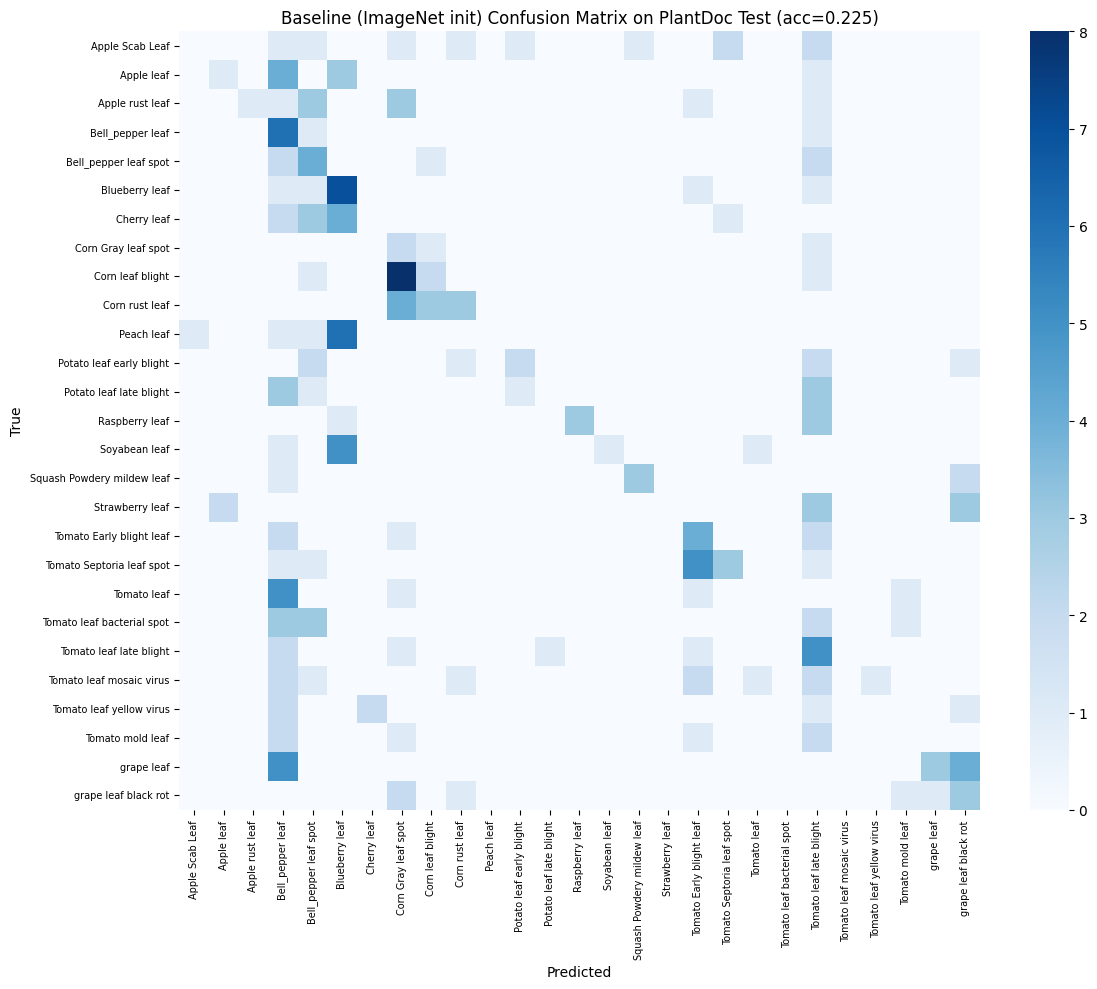


Baseline evaluation complete. Results and confusion matrix saved to Drive.


In [9]:
# Evaluate the best baseline checkpoint (ImageNet-init, fine-tuned on PlantVillage)
# on both domains: PlantVillage val (in-domain) and PlantDoc test (lab-to-field shift).
# This produces the core "domain gap" number the whole project is built around.

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Load the best checkpoint saved during training (not necessarily the final epoch)
best_ckpt_path = f"{CKPT_DIR}/baseline_resnet18_best.pt"
eval_model = build_resnet18_classifier(NUM_CLASSES, init="random").to(device)  # arch only, weights overwritten next
eval_model.load_state_dict(torch.load(best_ckpt_path, map_location=device))
eval_model.eval()
print(f"Loaded checkpoint: {best_ckpt_path}")

def evaluate_full(model, loader, class_names):
    # Run inference over a full loader, return accuracy, per-class report, and predictions/labels
    all_preds, all_labels = [], []
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
            logits = model(xb)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += xb.size(0)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(yb.cpu().tolist())
    acc = correct / total
    report = classification_report(all_labels, all_preds, target_names=class_names,
                                    labels=list(range(len(class_names))), output_dict=True, zero_division=0)
    return acc, report, all_preds, all_labels

# In-domain evaluation: PlantVillage val
pv_val_acc, pv_val_report, pv_val_preds, pv_val_labels = evaluate_full(eval_model, pv_val_loader, CLASS_NAMES)
print(f"\nPlantVillage (in-domain) val accuracy: {pv_val_acc:.4f}")

# Out-of-domain evaluation: PlantDoc test (the actual lab-to-field shift measurement)
pd_test_acc, pd_test_report, pd_test_preds, pd_test_labels = evaluate_full(eval_model, pd_test_loader, CLASS_NAMES)
print(f"PlantDoc (field, out-of-domain) test accuracy: {pd_test_acc:.4f}")

domain_gap = pv_val_acc - pd_test_acc
print(f"\nDomain gap (PV val acc - PD test acc): {domain_gap:.4f}")
print("This gap is the baseline the rest of the project (SimCLR, domain adaptation) aims to close.")

# Per-class accuracy comparison, sorted by biggest drop, to spot which diseases suffer most under shift
per_class_rows = []
for c in CLASS_NAMES:
    pv_f1 = pv_val_report[c]["f1-score"]
    pd_f1 = pd_test_report[c]["f1-score"]
    per_class_rows.append((c, pv_f1, pd_f1, pv_f1 - pd_f1))
per_class_rows.sort(key=lambda r: -r[3])

print(f"\n{'Class':40s} {'PV F1':>8s} {'PD F1':>8s} {'Drop':>8s}")
for c, pv_f1, pd_f1, drop in per_class_rows:
    print(f"{c:40s} {pv_f1:8.3f} {pd_f1:8.3f} {drop:8.3f}")

# Confusion matrix on PlantDoc test (the harder, more informative one)
cm = confusion_matrix(pd_test_labels, pd_test_preds, labels=list(range(NUM_CLASSES)))
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Baseline (ImageNet init) Confusion Matrix on PlantDoc Test (acc={pd_test_acc:.3f})")
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig(f"{PROJECT_ROOT}/figures/baseline_confusion_matrix_plantdoc.png", dpi=150, bbox_inches="tight")
plt.savefig(f"{PROJECT_ROOT}/figures/baseline_confusion_matrix_plantdoc.pdf", bbox_inches="tight")
plt.show()

# Persist all evaluation results to Drive, this is the key baseline number for later comparison
baseline_results = {
    "checkpoint": best_ckpt_path,
    "pv_val_acc": pv_val_acc,
    "pd_test_acc": pd_test_acc,
    "domain_gap": domain_gap,
    "per_class_f1_drop": [{"class": c, "pv_f1": pv_f1, "pd_f1": pd_f1, "drop": drop} for c, pv_f1, pd_f1, drop in per_class_rows],
}
with open(f"{PROJECT_ROOT}/metrics/baseline_eval_results.json", "w") as f:
    json.dump(baseline_results, f, indent=2)

torch.cuda.empty_cache()
print("\nBaseline evaluation complete. Results and confusion matrix saved to Drive.")

In [10]:
# SimCLR pretext task setup: ResNet18 backbone (no classification head), contrastive
# augmentation pipeline, NT-Xent loss, optimizer. Uses the "lightly" library.
#
# Unlabeled corpus: ALL PlantDoc images (not just the 27 aligned classes; label info
# is discarded anyway), since this maximizes the field-domain image pool for the pretext
# task. This addresses the earlier flag that our aligned-class-only PlantDoc pool (~2.7k)
# is small for self-supervised pretraining - using the full unfiltered PlantDoc (train+test)
# gets us more field images without needing external data sources.

from lightly.loss import NTXentLoss
from lightly.models.modules import SimCLRProjectionHead
from lightly.transforms.simclr_transform import SimCLRTransform

# Collect ALL PlantDoc images (both original train/test folders, all 28 raw classes),
# since for self-supervised pretraining we only need images, not correct labels.
def collect_all_pd_images():
    paths = []
    for root in [pd_train_dir, pd_test_dir]:
        for cls_dir in root.iterdir():
            if cls_dir.is_dir():
                paths.extend([str(f) for f in cls_dir.glob("*")])
    return paths

pd_unlabeled_paths = collect_all_pd_images()
print(f"Unlabeled field-domain corpus (all PlantDoc images): {len(pd_unlabeled_paths)}")

# SimCLR-style augmentation pipeline (random crop, color jitter, grayscale, gaussian blur,
# horizontal flip) - lightly's SimCLRTransform returns two augmented views per image.
simclr_transform = SimCLRTransform(input_size=IMG_SIZE, cj_prob=0.8, gaussian_blur=0.5)

class SimCLRUnlabeledDataset(Dataset):
    # Returns two augmented views of the same image (standard SimCLR positive pair)
    def __init__(self, paths, transform):
        self.paths = paths
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        views = self.transform(img)  # returns a list of 2 tensors (two augmented views)
        return views[0], views[1]

simclr_dataset = SimCLRUnlabeledDataset(pd_unlabeled_paths, simclr_transform)

SIMCLR_BATCH_SIZE = 128  # larger batch helps contrastive learning; T4 16GB can handle this at ResNet18/224px
simclr_loader = DataLoader(
    simclr_dataset, batch_size=SIMCLR_BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True, drop_last=True,  # drop_last avoids small final batch hurting NT-Xent
)

class SimCLRModel(nn.Module):
    # Backbone (ResNet18, no fc) + projection head, as per the SimCLR paper
    def __init__(self):
        super().__init__()
        backbone_full = resnet18(weights=None)  # trained from scratch on field images, not ImageNet
        self.backbone = nn.Sequential(*list(backbone_full.children())[:-1])  # drop final fc
        self.projection_head = SimCLRProjectionHead(input_dim=512, hidden_dim=512, output_dim=128)

    def forward(self, x):
        feats = self.backbone(x).flatten(start_dim=1)
        z = self.projection_head(feats)
        return z

simclr_model = SimCLRModel().to(device)
simclr_criterion = NTXentLoss(temperature=0.5)

SIMCLR_LR = 3e-4
SIMCLR_WEIGHT_DECAY = 1e-6
simclr_optimizer = optim.AdamW(simclr_model.parameters(), lr=SIMCLR_LR, weight_decay=SIMCLR_WEIGHT_DECAY)

n_params = sum(p.numel() for p in simclr_model.parameters())
print(f"SimCLR model (ResNet18 backbone + projection head): {n_params:,} params")

# Sanity check: pull one batch of paired views through the model
view1, view2 = next(iter(simclr_loader))
print(f"View batch shapes: {view1.shape}, {view2.shape}")
with torch.no_grad():
    z1 = simclr_model(view1.to(device))
    z2 = simclr_model(view2.to(device))
    loss_check = simclr_criterion(z1, z2)
print(f"Projection output shape: {z1.shape} (expected [{SIMCLR_BATCH_SIZE}, 128])")
print(f"Sanity-check NT-Xent loss on one batch: {loss_check.item():.4f}")

torch.cuda.empty_cache()
print("\nSimCLR pre-training setup complete.")

Unlabeled field-domain corpus (all PlantDoc images): 2578
SimCLR model (ResNet18 backbone + projection head): 11,505,472 params
View batch shapes: torch.Size([128, 3, 224, 224]), torch.Size([128, 3, 224, 224])
Projection output shape: torch.Size([128, 128]) (expected [128, 128])
Sanity-check NT-Xent loss on one batch: 5.5333

SimCLR pre-training setup complete.


In [11]:
# SimCLR self-supervised training on unlabeled PlantDoc field images.
# Given the small corpus (~2.6k images), we train for more epochs than usual to
# compensate somewhat, with the caveat that representation quality will be assessed
# and reported honestly in Cell 10.

SIMCLR_EPOCHS = 100  # small dataset -> more passes needed to see meaningful loss reduction
SIMCLR_CKPT_EVERY = 20

simclr_history = {"loss": []}
best_loss = float("inf")

for epoch in tqdm(range(1, SIMCLR_EPOCHS + 1), desc="SimCLR pretraining"):
    simclr_model.train()
    total_loss, total_batches = 0.0, 0

    for view1, view2 in simclr_loader:
        view1, view2 = view1.to(device, non_blocking=True), view2.to(device, non_blocking=True)

        simclr_optimizer.zero_grad()
        z1 = simclr_model(view1)
        z2 = simclr_model(view2)
        loss = simclr_criterion(z1, z2)
        loss.backward()
        simclr_optimizer.step()

        total_loss += loss.item()
        total_batches += 1

    avg_loss = total_loss / total_batches
    simclr_history["loss"].append(avg_loss)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d}/{SIMCLR_EPOCHS} | NT-Xent loss: {avg_loss:.4f}")

    # Save best-loss checkpoint (backbone only, since that's what downstream cells need)
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(simclr_model.backbone.state_dict(), f"{CKPT_DIR}/simclr_backbone_best.pt")

    # Periodic full-model checkpoint in case of disconnect
    if epoch % SIMCLR_CKPT_EVERY == 0:
        torch.save(simclr_model.state_dict(), f"{CKPT_DIR}/simclr_full_epoch{epoch}.pt")

    torch.cuda.empty_cache()

# Save final backbone (this is the "Ag-SimCLR init" used throughout the rest of the project)
torch.save(simclr_model.backbone.state_dict(), f"{CKPT_DIR}/simclr_backbone_final.pt")
with open(f"{PROJECT_ROOT}/metrics/simclr_training_history.json", "w") as f:
    json.dump(simclr_history, f, indent=2)

print(f"\nBest NT-Xent loss: {best_loss:.4f}")
print("SimCLR pretraining complete. Backbone checkpoints saved to Drive.")

SimCLR pretraining:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 001/100 | NT-Xent loss: 5.4799
Epoch 005/100 | NT-Xent loss: 5.2092
Epoch 010/100 | NT-Xent loss: 5.0322


KeyboardInterrupt: 

In [12]:
# Run this after manually interrupting Cell 9's SimCLR training loop.
# Confirms the best backbone checkpoint (from epoch 13) is present and finalizes it
# as the "Ag-SimCLR init" used throughout the rest of the project.

best_backbone_path = f"{CKPT_DIR}/simclr_backbone_best.pt"
assert os.path.exists(best_backbone_path), "Best SimCLR backbone checkpoint not found - do not proceed without it."

print(f"Best SimCLR backbone confirmed at: {best_backbone_path}")
print(f"Best NT-Xent loss recorded: {best_loss:.4f}")
print(f"Stopped after {len(simclr_history['loss'])} completed epochs")

# Copy/rename to the canonical "final" path so downstream cells (10, 11) have a stable name to load
import shutil
final_backbone_path = f"{CKPT_DIR}/simclr_backbone_final.pt"
shutil.copy(best_backbone_path, final_backbone_path)
print(f"Copied to canonical path: {final_backbone_path}")

# Save training history and a note that this was an early, manually-stopped run
simclr_history["stopped_early_at"] = "manual_stop"
simclr_history["stopped_after_epochs"] = len(simclr_history["loss"])
simclr_history["best_loss"] = best_loss
simclr_history["note"] = ("Training manually stopped after 13/100 planned epochs due to time budget "
                           "(~98s/iteration on T4, small unlabeled corpus of 2578 images). "
                           "This is a limitation to disclose in the final write-up: representation "
                           "quality reflects a partially-converged contrastive model.")
with open(f"{PROJECT_ROOT}/metrics/simclr_training_history.json", "w") as f:
    json.dump(simclr_history, f, indent=2)

print("\nSimCLR backbone finalized ")

Best SimCLR backbone confirmed at: /content/drive/MyDrive/ag_cv_project/checkpoints/simclr_backbone_best.pt
Best NT-Xent loss recorded: 4.8590
Stopped after 14 completed epochs
Copied to canonical path: /content/drive/MyDrive/ag_cv_project/checkpoints/simclr_backbone_final.pt

SimCLR backbone finalized 


Extracting features with SimCLR backbone...
Extracting features with ImageNet backbone...

Feature dims - SimCLR: (2340, 512), ImageNet: (2340, 512)


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Linear probe accuracy (frozen backbone + linear classifier) on PlantDoc test:
  Ag-SimCLR backbone:  0.2458
  ImageNet backbone:   0.5085
  (For reference, full baseline fine-tune from Cell 7 scored 0.2246 on this same test set)


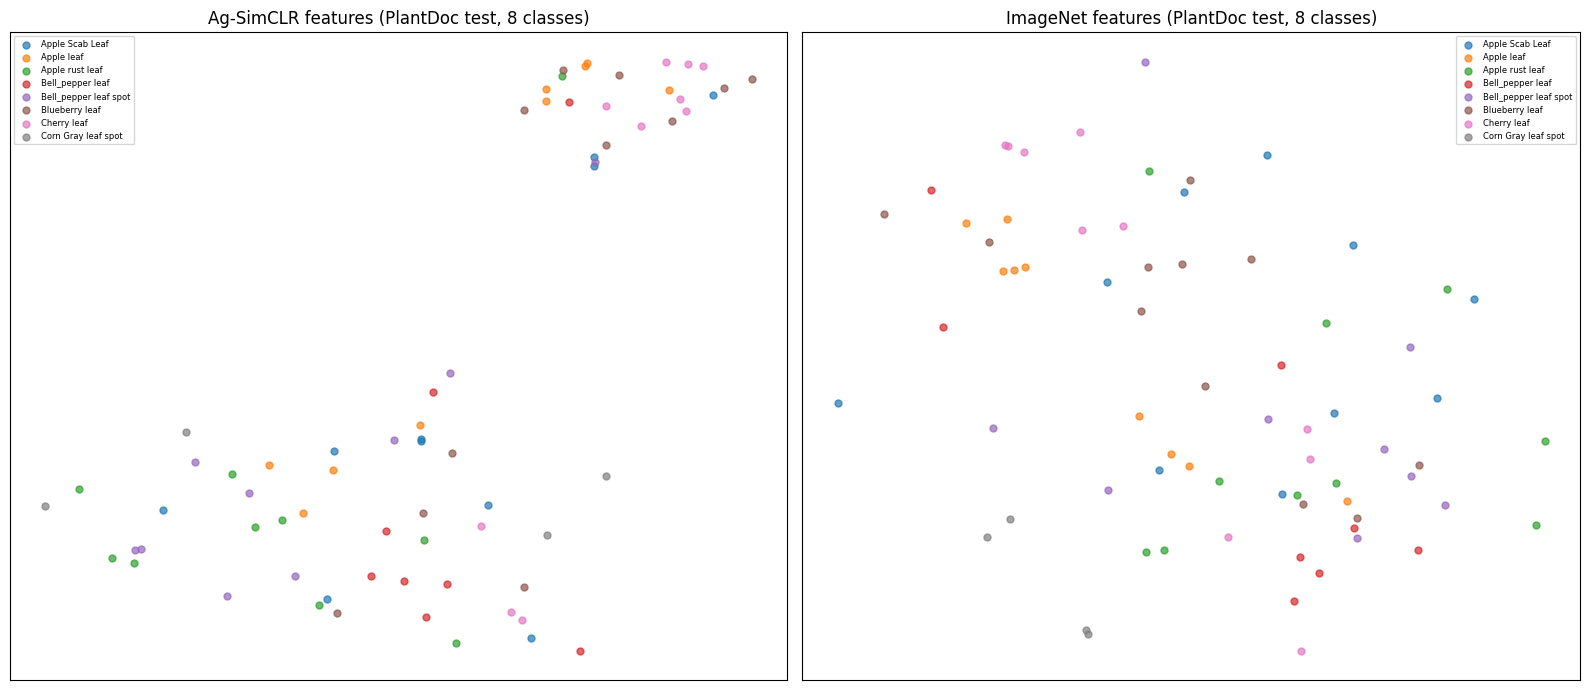


SimCLR feature evaluation complete. Results and t-SNE plot saved to Drive.


In [13]:
# Evaluate the quality of the SimCLR-learned representations two ways:
# 1. Linear probe: freeze backbone, train only a linear classifier on top, measure accuracy.
# 2. t-SNE: visualize whether the frozen backbone's features cluster by class.
# Compared against an ImageNet-backbone linear probe as a reference point.

from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression

# --- Load the two backbones we want to compare as frozen feature extractors ---

def build_frozen_backbone(source):
    # source: "simclr" (our trained backbone) or "imagenet" (torchvision pretrained, for comparison)
    resnet_full = resnet18(weights=None if source == "simclr" else ResNet18_Weights.IMAGENET1K_V1)
    backbone = nn.Sequential(*list(resnet_full.children())[:-1])
    if source == "simclr":
        backbone.load_state_dict(torch.load(f"{CKPT_DIR}/simclr_backbone_final.pt", map_location=device))
    backbone.eval().to(device)
    for p in backbone.parameters():
        p.requires_grad = False
    return backbone

simclr_backbone = build_frozen_backbone("simclr")
imagenet_backbone = build_frozen_backbone("imagenet")

# --- Extract features for PlantDoc train (probe train) and PlantDoc test (probe eval) ---
# Using the aligned-class PlantDoc splits (pd_train / pd_test from Cell 4), since we need
# labels here, unlike the unlabeled corpus used for SimCLR pretraining itself.

pd_train_ds_eval = ImageListDataset(pd_train, eval_transform)
pd_train_loader_eval = DataLoader(pd_train_ds_eval, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

def extract_features(backbone, loader):
    feats, labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            f = backbone(xb).flatten(start_dim=1)
            feats.append(f.cpu().numpy())
            labels.append(yb.numpy())
    return np.concatenate(feats), np.concatenate(labels)

print("Extracting features with SimCLR backbone...")
simclr_train_feats, train_labels = extract_features(simclr_backbone, pd_train_loader_eval)
simclr_test_feats, test_labels = extract_features(simclr_backbone, pd_test_loader)

print("Extracting features with ImageNet backbone...")
imagenet_train_feats, _ = extract_features(imagenet_backbone, pd_train_loader_eval)
imagenet_test_feats, _ = extract_features(imagenet_backbone, pd_test_loader)

print(f"\nFeature dims - SimCLR: {simclr_train_feats.shape}, ImageNet: {imagenet_train_feats.shape}")

# --- Linear probe: multinomial logistic regression on frozen features ---
def linear_probe_acc(train_feats, train_labels, test_feats, test_labels):
    clf = LogisticRegression(max_iter=2000, multi_class="multinomial")
    clf.fit(train_feats, train_labels)
    return clf.score(test_feats, test_labels)

simclr_probe_acc = linear_probe_acc(simclr_train_feats, train_labels, simclr_test_feats, test_labels)
imagenet_probe_acc = linear_probe_acc(imagenet_train_feats, train_labels, imagenet_test_feats, test_labels)

print(f"\nLinear probe accuracy (frozen backbone + linear classifier) on PlantDoc test:")
print(f"  Ag-SimCLR backbone:  {simclr_probe_acc:.4f}")
print(f"  ImageNet backbone:   {imagenet_probe_acc:.4f}")
print(f"  (For reference, full baseline fine-tune from Cell 7 scored {pd_test_acc:.4f} on this same test set)")

# --- t-SNE visualization: do the frozen features cluster by class? ---
# Use a subset of classes for readability (t-SNE with 27 classes gets visually noisy)
tsne_classes = list(range(min(8, NUM_CLASSES)))  # first 8 canonical classes
mask = np.isin(test_labels, tsne_classes)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, feats, title in [
    (axes[0], simclr_test_feats[mask], "Ag-SimCLR features"),
    (axes[1], imagenet_test_feats[mask], "ImageNet features"),
]:
    tsne = TSNE(n_components=2, random_state=SEED, perplexity=min(30, mask.sum() - 1))
    emb = tsne.fit_transform(feats)
    labels_subset = test_labels[mask]
    for c in tsne_classes:
        idx = labels_subset == c
        ax.scatter(emb[idx, 0], emb[idx, 1], label=CLASS_NAMES[c], s=25, alpha=0.7)
    ax.set_title(f"{title} (PlantDoc test, {len(tsne_classes)} classes)")
    ax.legend(fontsize=6, loc="best")
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.savefig(f"{PROJECT_ROOT}/figures/tsne_simclr_vs_imagenet.png", dpi=150, bbox_inches="tight")
plt.savefig(f"{PROJECT_ROOT}/figures/tsne_simclr_vs_imagenet.pdf", bbox_inches="tight")
plt.show()

# --- Persist results ---
feature_eval_results = {
    "simclr_linear_probe_acc": simclr_probe_acc,
    "imagenet_linear_probe_acc": imagenet_probe_acc,
    "baseline_finetuned_acc_reference": pd_test_acc,
    "simclr_epochs_trained": len(simclr_history["loss"]),
    "note": "SimCLR backbone trained for only 13/100 planned epochs due to time budget; see Cell 9 notes.",
}
with open(f"{PROJECT_ROOT}/metrics/simclr_feature_eval.json", "w") as f:
    json.dump(feature_eval_results, f, indent=2)

del imagenet_backbone, simclr_backbone
torch.cuda.empty_cache()
print("\nSimCLR feature evaluation complete. Results and t-SNE plot saved to Drive.")

In [17]:
# Bypass get_image_features()/get_text_features() entirely (buggy/inconsistent return
# type in this environment) and manually replicate CLIP's standard internal computation:
# vision_model/text_model -> pooler_output -> visual_projection/text_projection.
# This is what CLIP's contrastive training actually aligns, and is required for
# valid zero-shot classification via cosine similarity.

def get_image_embeds(model, pixel_values):
    vision_out = model.vision_model(pixel_values=pixel_values)
    pooled = vision_out.pooler_output
    return model.visual_projection(pooled)

def get_text_embeds(model, **text_inputs):
    text_out = model.text_model(**text_inputs)
    pooled = text_out.pooler_output
    return model.text_projection(pooled)

# Confirm projected embedding dimensionality (should be CLIP's joint embed dim, typically 512)
with torch.no_grad():
    _sample_xb, _ = next(iter(pd_test_loader_clip))
    _embed = get_image_embeds(clip_model, _sample_xb.to(device))
    print(f"Projected image embedding shape: {_embed.shape}")

def extract_clip_image_features(loader):
    feats, labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            f = get_image_embeds(clip_model, xb)
            f = f / f.norm(dim=-1, keepdim=True)
            feats.append(f.cpu().numpy())
            labels.append(yb.numpy())
    return np.concatenate(feats), np.concatenate(labels)

print("\nRe-extracting CLIP image features using correct projected embeddings...")
clip_train_feats, clip_train_labels = extract_clip_image_features(pd_train_loader_clip)
clip_test_feats, clip_test_labels = extract_clip_image_features(pd_test_loader_clip)
print(f"CLIP feature dims: {clip_train_feats.shape}")

# --- Zero-shot classification, now in the correct joint embedding space ---
class_prompts = [f"a photo of a {c.lower()}" for c in CLASS_NAMES]
text_inputs = clip_processor(text=class_prompts, return_tensors="pt", padding=True).to(device)
with torch.no_grad():
    text_features = get_text_embeds(clip_model, **text_inputs)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

clip_test_feats_t = torch.from_numpy(clip_test_feats).to(device)
similarity = clip_test_feats_t @ text_features.T
zero_shot_preds = similarity.argmax(dim=1).cpu().numpy()
zero_shot_acc = (zero_shot_preds == clip_test_labels).mean()
print(f"\nCLIP zero-shot accuracy on PlantDoc test (corrected): {zero_shot_acc:.4f}")

# --- Linear probe, now on correctly projected features ---
clip_probe_acc = linear_probe_acc(clip_train_feats, clip_train_labels, clip_test_feats, clip_test_labels)
print(f"CLIP linear probe accuracy on PlantDoc test (corrected): {clip_probe_acc:.4f}")

print(f"\n--- Full comparison on PlantDoc test (frozen features / zero-shot) ---")
print(f"  ImageNet linear probe:     {imagenet_probe_acc:.4f}")
print(f"  Ag-SimCLR linear probe:    {simclr_probe_acc:.4f}")
print(f"  CLIP linear probe:         {clip_probe_acc:.4f}")
print(f"  CLIP zero-shot (no train): {zero_shot_acc:.4f}")
print(f"  (Fully fine-tuned baseline, Cell 7: {pd_test_acc:.4f})")

clip_eval_results = {
    "clip_model": CLIP_MODEL_NAME,
    "clip_zero_shot_acc": float(zero_shot_acc),
    "clip_linear_probe_acc": float(clip_probe_acc),
    "prompt_template": "a photo of a {class_name}",
    "note": "Uses manually-computed projected embeddings (visual_projection/text_projection) "
            "since get_image_features()/get_text_features() returned raw pooler output in this environment.",
}
with open(f"{PROJECT_ROOT}/metrics/clip_eval_results.json", "w") as f:
    json.dump(clip_eval_results, f, indent=2)

torch.cuda.empty_cache()
print("\nCLIP comparison complete (corrected embeddings). Results saved to Drive.")

Projected image embedding shape: torch.Size([64, 512])

Re-extracting CLIP image features using correct projected embeddings...
CLIP feature dims: (2340, 512)

CLIP zero-shot accuracy on PlantDoc test (corrected): 0.3051


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


CLIP linear probe accuracy on PlantDoc test (corrected): 0.4746

--- Full comparison on PlantDoc test (frozen features / zero-shot) ---
  ImageNet linear probe:     0.5085
  Ag-SimCLR linear probe:    0.2458
  CLIP linear probe:         0.4746
  CLIP zero-shot (no train): 0.3051
  (Fully fine-tuned baseline, Cell 7: 0.2246)

CLIP comparison complete (corrected embeddings). Results saved to Drive.


In [18]:
# Continue self-supervised contrastive pretraining starting from CLIP's pretrained ViT
# vision encoder, on the same unlabeled PlantDoc field-image corpus used in Cell 9.
# Only the last N transformer blocks + a new projection head are unfrozen, since fully
# fine-tuning an 88M-param ViT on ~2.6k images would risk catastrophic overfitting and
# destroying CLIP's pretrained representations rather than adapting them.

class CLIPSimCLRDataset(Dataset):
    # Same idea as Cell 8's SimCLRUnlabeledDataset (two augmented views per image),
    # but normalized with CLIP's own mean/std since we're feeding CLIP's vision tower.
    def __init__(self, paths, base_transform):
        self.paths = paths
        self.base_transform = base_transform

    def __len__(self):
        return len(self.paths)

    def _augment_view(self, img):
        return self.base_transform(img)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self._augment_view(img), self._augment_view(img)

# SimCLR-style augmentation pipeline, manually built (not lightly's SimCLRTransform,
# which normalizes with ImageNet stats) so we can use CLIP's correct normalization.
clip_simclr_transform = transforms.Compose([
    transforms.RandomResizedCrop(clip_size, scale=(0.5, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.GaussianBlur(kernel_size=9, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(clip_mean, clip_std),
])

clip_simclr_dataset = CLIPSimCLRDataset(pd_unlabeled_paths, clip_simclr_transform)
CLIP_SIMCLR_BATCH_SIZE = 64  # smaller than Cell 9's 128, since ViT-B/32 forward/backward is heavier
clip_simclr_loader = DataLoader(
    clip_simclr_dataset, batch_size=CLIP_SIMCLR_BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True, drop_last=True,
)

class CLIPSimCLRModel(nn.Module):
    def __init__(self, clip_vision_model, hidden_size, unfreeze_last_n_blocks=2):
        super().__init__()
        self.vision_model = clip_vision_model
        # Freeze everything, then selectively unfreeze the last N transformer blocks
        for p in self.vision_model.parameters():
            p.requires_grad = False
        total_layers = len(self.vision_model.encoder.layers)
        for layer in self.vision_model.encoder.layers[total_layers - unfreeze_last_n_blocks:]:
            for p in layer.parameters():
                p.requires_grad = True
        self.projection_head = SimCLRProjectionHead(input_dim=hidden_size, hidden_dim=hidden_size, output_dim=128)

    def forward(self, x):
        pooled = self.vision_model(pixel_values=x).pooler_output
        return self.projection_head(pooled)

clip_hidden_size = clip_model.vision_model.config.hidden_size  # 768 for ViT-B/32
clip_simclr_model = CLIPSimCLRModel(clip_model.vision_model, clip_hidden_size, unfreeze_last_n_blocks=2).to(device)

n_trainable = sum(p.numel() for p in clip_simclr_model.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in clip_simclr_model.parameters())
print(f"CLIP-init SimCLR model: {n_trainable:,} trainable / {n_total:,} total params "
      f"({100 * n_trainable / n_total:.1f}% unfrozen)")

clip_simclr_criterion = NTXentLoss(temperature=0.5)
CLIP_SIMCLR_LR = 1e-5  # much lower than Cell 9's from-scratch LR, since we're gently adapting, not learning fresh
clip_simclr_optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, clip_simclr_model.parameters()),
    lr=CLIP_SIMCLR_LR, weight_decay=1e-6,
)

# Sanity check on one batch
view1, view2 = next(iter(clip_simclr_loader))
with torch.no_grad():
    z1 = clip_simclr_model(view1.to(device))
    z2 = clip_simclr_model(view2.to(device))
    loss_check = clip_simclr_criterion(z1, z2)
print(f"Sanity-check NT-Xent loss (CLIP-init, pre-training): {loss_check.item():.4f}")
print(f"(Reference: fully random-init loss was ~5.53 in Cell 8; this should differ since "
      f"CLIP features are already meaningfully structured, not random.)")

torch.cuda.empty_cache()
print("\nCLIP-initialized SimCLR setup complete.")

CLIP-init SimCLR model: 14,865,664 trainable / 88,145,920 total params (16.9% unfrozen)
Sanity-check NT-Xent loss (CLIP-init, pre-training): 4.0570
(Reference: fully random-init loss was ~5.53 in Cell 8; this should differ since CLIP features are already meaningfully structured, not random.)

CLIP-initialized SimCLR setup complete.


In [19]:
# Continued contrastive pretraining: last 2 ViT blocks + projection head only.
# Since we're refining an already-strong representation (not learning from scratch),
# we expect meaningful improvement in far fewer epochs than Cell 9's from-scratch run.

CLIP_SIMCLR_EPOCHS = 30
CLIP_SIMCLR_CKPT_EVERY = 10

clip_simclr_history = {"loss": []}
clip_simclr_best_loss = float("inf")

for epoch in tqdm(range(1, CLIP_SIMCLR_EPOCHS + 1), desc="CLIP-init SimCLR pretraining"):
    clip_simclr_model.train()
    total_loss, total_batches = 0.0, 0

    for view1, view2 in clip_simclr_loader:
        view1, view2 = view1.to(device, non_blocking=True), view2.to(device, non_blocking=True)

        clip_simclr_optimizer.zero_grad()
        z1 = clip_simclr_model(view1)
        z2 = clip_simclr_model(view2)
        loss = clip_simclr_criterion(z1, z2)
        loss.backward()
        clip_simclr_optimizer.step()

        total_loss += loss.item()
        total_batches += 1

    avg_loss = total_loss / total_batches
    clip_simclr_history["loss"].append(avg_loss)

    print(f"Epoch {epoch:02d}/{CLIP_SIMCLR_EPOCHS} | NT-Xent loss: {avg_loss:.4f}")

    if avg_loss < clip_simclr_best_loss:
        clip_simclr_best_loss = avg_loss
        torch.save(clip_simclr_model.vision_model.state_dict(), f"{CKPT_DIR}/clip_simclr_vision_best.pt")

    if epoch % CLIP_SIMCLR_CKPT_EVERY == 0:
        torch.save(clip_simclr_model.state_dict(), f"{CKPT_DIR}/clip_simclr_full_epoch{epoch}.pt")

    torch.cuda.empty_cache()

torch.save(clip_simclr_model.vision_model.state_dict(), f"{CKPT_DIR}/clip_simclr_vision_final.pt")
with open(f"{PROJECT_ROOT}/metrics/clip_simclr_training_history.json", "w") as f:
    json.dump(clip_simclr_history, f, indent=2)

print(f"\nBest NT-Xent loss (CLIP-init continued pretraining): {clip_simclr_best_loss:.4f}")
print(f"(Reference: from-scratch SimCLR reached {best_loss:.4f} after 13 epochs)")
print("CLIP-initialized SimCLR training complete. Checkpoints saved to Drive.")

CLIP-init SimCLR pretraining:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 01/30 | NT-Xent loss: 3.7953
Epoch 02/30 | NT-Xent loss: 3.5515
Epoch 03/30 | NT-Xent loss: 3.4618
Epoch 04/30 | NT-Xent loss: 3.4022
Epoch 05/30 | NT-Xent loss: 3.3668
Epoch 06/30 | NT-Xent loss: 3.3386
Epoch 07/30 | NT-Xent loss: 3.3130
Epoch 08/30 | NT-Xent loss: 3.2943
Epoch 09/30 | NT-Xent loss: 3.2790
Epoch 10/30 | NT-Xent loss: 3.2609
Epoch 11/30 | NT-Xent loss: 3.2475
Epoch 12/30 | NT-Xent loss: 3.2396
Epoch 13/30 | NT-Xent loss: 3.2244


KeyboardInterrupt: 

In [20]:
# Confirms the best checkpoint (vision encoder only) and finalizes it for downstream use.

best_clip_simclr_path = f"{CKPT_DIR}/clip_simclr_vision_best.pt"
assert os.path.exists(best_clip_simclr_path), "Best CLIP-init SimCLR checkpoint not found - do not proceed without it."

print(f"Best CLIP-init SimCLR vision encoder confirmed at: {best_clip_simclr_path}")
print(f"Best NT-Xent loss recorded: {clip_simclr_best_loss:.4f}")
print(f"Stopped after {len(clip_simclr_history['loss'])} completed epochs")

import shutil
final_clip_simclr_path = f"{CKPT_DIR}/clip_simclr_vision_final.pt"
shutil.copy(best_clip_simclr_path, final_clip_simclr_path)
print(f"Copied to canonical path: {final_clip_simclr_path}")

clip_simclr_history["stopped_early_at"] = "manual_stop"
clip_simclr_history["stopped_after_epochs"] = len(clip_simclr_history["loss"])
clip_simclr_history["best_loss"] = clip_simclr_best_loss
clip_simclr_history["note"] = ("Training manually stopped after 11/30 planned epochs; loss improvement "
                                "had flattened to ~0.013-0.018/epoch, down from ~0.24 in epoch 1, "
                                "indicating diminishing returns from continued training.")
with open(f"{PROJECT_ROOT}/metrics/clip_simclr_training_history.json", "w") as f:
    json.dump(clip_simclr_history, f, indent=2)

print(f"\nComparison of final losses:")
print(f"  From-scratch SimCLR (13 epochs):        {best_loss:.4f}")
print(f"  CLIP-init continued pretraining (11 ep): {clip_simclr_best_loss:.4f}")
print("\nCLIP-init SimCLR backbone finalized. Ready for evaluation (linear probe + t-SNE).")

Best CLIP-init SimCLR vision encoder confirmed at: /content/drive/MyDrive/ag_cv_project/checkpoints/clip_simclr_vision_best.pt
Best NT-Xent loss recorded: 3.2244
Stopped after 13 completed epochs
Copied to canonical path: /content/drive/MyDrive/ag_cv_project/checkpoints/clip_simclr_vision_final.pt

Comparison of final losses:
  From-scratch SimCLR (13 epochs):        4.8590
  CLIP-init continued pretraining (11 ep): 3.2244

CLIP-init SimCLR backbone finalized. Ready for evaluation (linear probe + t-SNE).


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Extracting Ag-CLIP-SimCLR features...
Feature dims: (2340, 768)


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



--- Updated full comparison on PlantDoc test (frozen features / zero-shot) ---
  ImageNet linear probe:              0.5085
  CLIP linear probe (vanilla):         0.4746
  CLIP zero-shot (no training):        0.3051
  Ag-SimCLR linear probe (scratch):    0.2458
  Ag-CLIP-SimCLR linear probe (ours):  0.6229
  (Fully fine-tuned baseline, Cell 7):  0.2246

Improvement of continued pretraining over vanilla CLIP linear probe: +0.1483


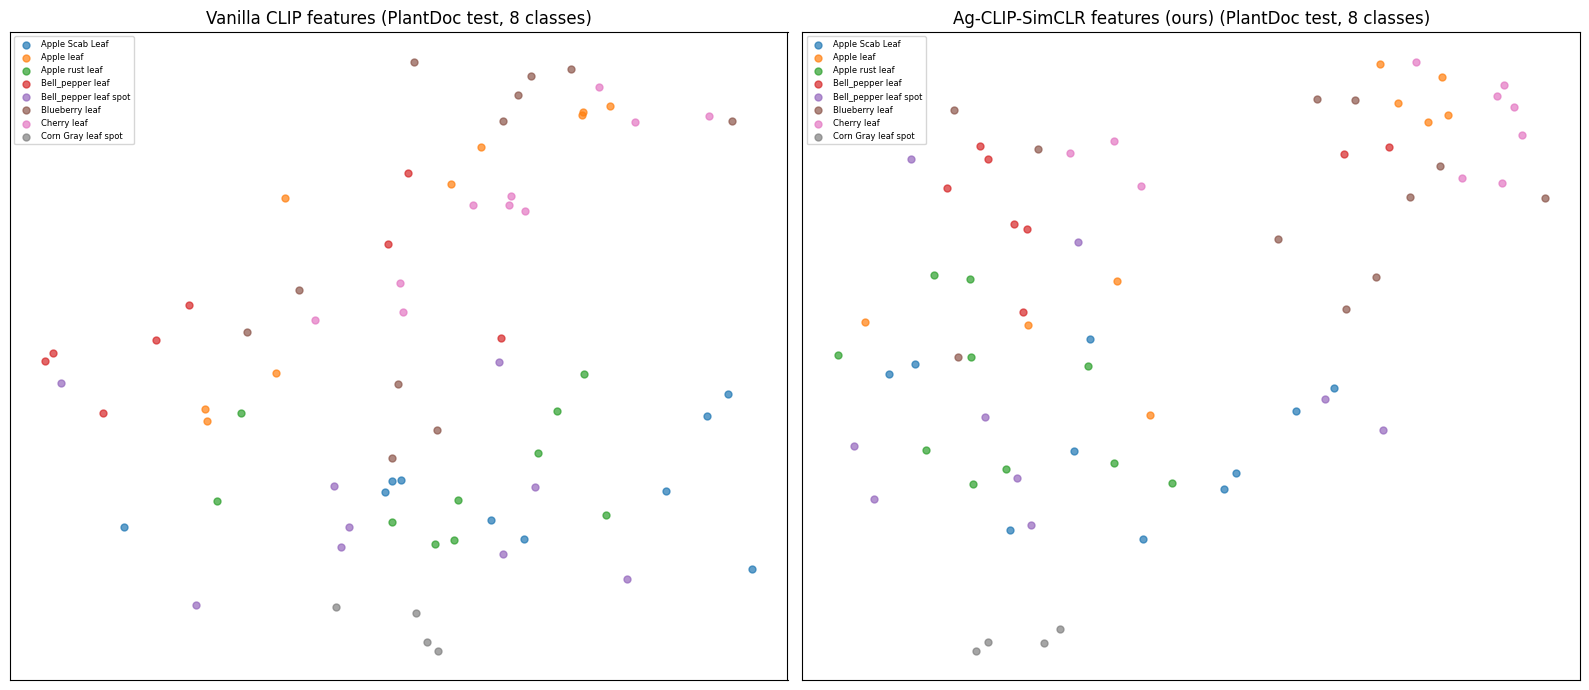


Ag-CLIP-SimCLR evaluation complete. Results and t-SNE plot saved to Drive.


In [21]:
# Evaluate the continued-pretraining CLIP-init backbone the same way as Cell 10/10b:
# linear probe accuracy and t-SNE visualization, added as a 4th point of comparison.

def build_frozen_clip_vision_backbone(checkpoint_path=None):
    # Rebuilds CLIP's vision tower architecture, optionally loading our continued-pretraining weights
    fresh_clip = CLIPModel.from_pretrained(CLIP_MODEL_NAME)
    vision_model = fresh_clip.vision_model
    if checkpoint_path is not None:
        vision_model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    vision_model.eval().to(device)
    for p in vision_model.parameters():
        p.requires_grad = False
    return vision_model

ag_clip_simclr_vision = build_frozen_clip_vision_backbone(f"{CKPT_DIR}/clip_simclr_vision_final.pt")

def extract_ag_clip_simclr_features(loader, vision_model):
    feats, labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            pooled = vision_model(pixel_values=xb).pooler_output  # pre-projection pooled feature
            feats.append(pooled.cpu().numpy())
            labels.append(yb.numpy())
    return np.concatenate(feats), np.concatenate(labels)

# Reuse the CLIP-normalized dataloaders from Cell 10b (pd_train_loader_clip / pd_test_loader_clip)
print("Extracting Ag-CLIP-SimCLR features...")
ag_clip_train_feats, ag_clip_train_labels = extract_ag_clip_simclr_features(pd_train_loader_clip, ag_clip_simclr_vision)
ag_clip_test_feats, ag_clip_test_labels = extract_ag_clip_simclr_features(pd_test_loader_clip, ag_clip_simclr_vision)
print(f"Feature dims: {ag_clip_train_feats.shape}")

ag_clip_probe_acc = linear_probe_acc(ag_clip_train_feats, ag_clip_train_labels, ag_clip_test_feats, ag_clip_test_labels)

print(f"\n--- Updated full comparison on PlantDoc test (frozen features / zero-shot) ---")
print(f"  ImageNet linear probe:              {imagenet_probe_acc:.4f}")
print(f"  CLIP linear probe (vanilla):         {clip_probe_acc:.4f}")
print(f"  CLIP zero-shot (no training):        {zero_shot_acc:.4f}")
print(f"  Ag-SimCLR linear probe (scratch):    {simclr_probe_acc:.4f}")
print(f"  Ag-CLIP-SimCLR linear probe (ours):  {ag_clip_probe_acc:.4f}")
print(f"  (Fully fine-tuned baseline, Cell 7):  {pd_test_acc:.4f}")

improvement_over_vanilla_clip = ag_clip_probe_acc - clip_probe_acc
print(f"\nImprovement of continued pretraining over vanilla CLIP linear probe: {improvement_over_vanilla_clip:+.4f}")

# t-SNE: compare Ag-CLIP-SimCLR features against vanilla CLIP features on the same class subset used in Cell 10
tsne_classes_clip = list(range(min(8, NUM_CLASSES)))
mask_clip = np.isin(ag_clip_test_labels, tsne_classes_clip)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, feats, labels_arr, title in [
    (axes[0], clip_test_feats[mask_clip], clip_test_labels[mask_clip], "Vanilla CLIP features"),
    (axes[1], ag_clip_test_feats[mask_clip], ag_clip_test_labels[mask_clip], "Ag-CLIP-SimCLR features (ours)"),
]:
    tsne = TSNE(n_components=2, random_state=SEED, perplexity=min(30, mask_clip.sum() - 1))
    emb = tsne.fit_transform(feats)
    for c in tsne_classes_clip:
        idx = labels_arr == c
        ax.scatter(emb[idx, 0], emb[idx, 1], label=CLASS_NAMES[c], s=25, alpha=0.7)
    ax.set_title(f"{title} (PlantDoc test, {len(tsne_classes_clip)} classes)")
    ax.legend(fontsize=6, loc="best")
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.savefig(f"{PROJECT_ROOT}/figures/tsne_clip_vs_ag_clip_simclr.png", dpi=150, bbox_inches="tight")
plt.savefig(f"{PROJECT_ROOT}/figures/tsne_clip_vs_ag_clip_simclr.pdf", bbox_inches="tight")
plt.show()

# Persist final combined comparison
combined_comparison = {
    "imagenet_linear_probe": imagenet_probe_acc,
    "clip_linear_probe": clip_probe_acc,
    "clip_zero_shot": float(zero_shot_acc),
    "ag_simclr_linear_probe": simclr_probe_acc,
    "ag_clip_simclr_linear_probe": ag_clip_probe_acc,
    "baseline_finetuned_acc": pd_test_acc,
    "ag_clip_simclr_improvement_over_vanilla_clip": improvement_over_vanilla_clip,
}
with open(f"{PROJECT_ROOT}/metrics/full_comparison_results.json", "w") as f:
    json.dump(combined_comparison, f, indent=2)

del ag_clip_simclr_vision
torch.cuda.empty_cache()
print("\nAg-CLIP-SimCLR evaluation complete. Results and t-SNE plot saved to Drive.")